In [1]:
from scripts.final_manuscript.plotting import data
from scripts.final_manuscript.plotting.plots import (
    cell_size,
    formatting,
    gamma,
    t_ind_vs_equivalence,
    velocity,
)

formatting.set_style()

cell_size_data_all = data.load_cell_size_data()
cell_size_data_measured = cell_size_data_all[cell_size_data_all["method"] == "measured"]
cell_size_data_simulated = cell_size_data_all[cell_size_data_all["method"] == "simulated"]
cell_size_data_ratio = data.calculate_simulated_measured_ratio(
    simulated=cell_size_data_simulated,
    measured=cell_size_data_measured,
)
sim_bulk_properties = data.load_cp_cv_sim_bulk_properties()
sim_bulk_property_ratios = data.calculate_cp_cv_gamma_ratios(sim_bulk_properties)
sim_conditions = data.load_sim_conditions()
sim_inert = data.load_sim_inert()
sim_inert_and_active = data.combine_inert_and_active(inert=sim_inert, active=sim_conditions)
cell_size_data_ratio_inert = data.calculate_simulated_measured_ratio(
    simulated=sim_inert_and_active[sim_inert_and_active["diluent_kind"] == "inert"],
    measured=cell_size_data_measured,
)

/home/mick/projects/DetResearch/funcs/simulation/interpolate.py:52: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out = pd.concat((out, co2, n2_new))


---
## Cell Size

### Measured Cell Size

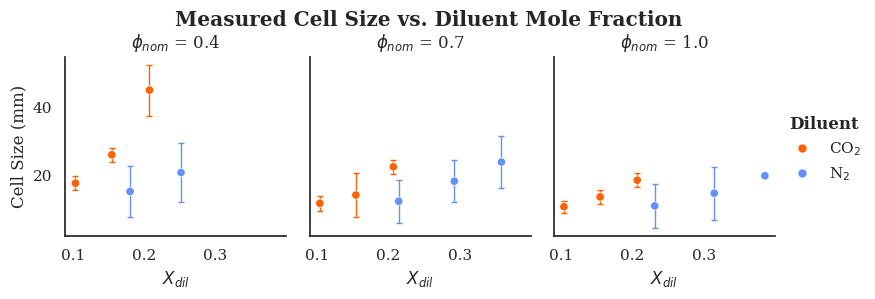

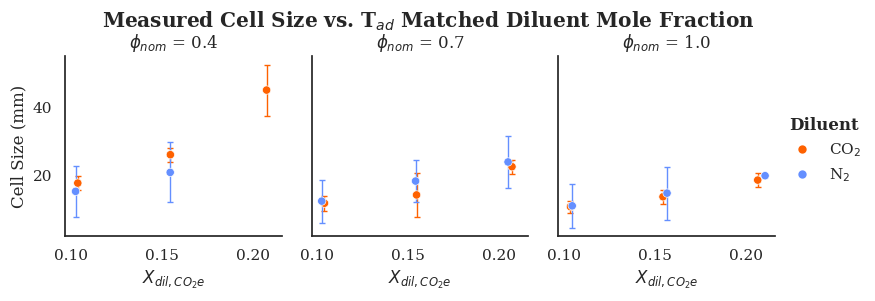

In [2]:
cell_size.measured_vs_raw_mole_concentration.plot(cell_size_data_measured)
cell_size.measured_vs_co2_tad_normalized.plot(cell_size_data_measured)

### Simulated Cell Size

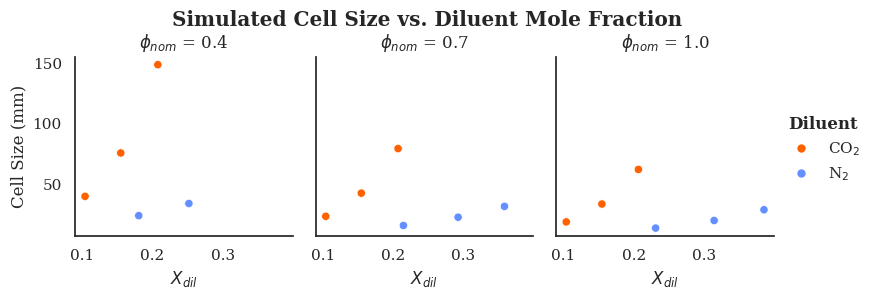

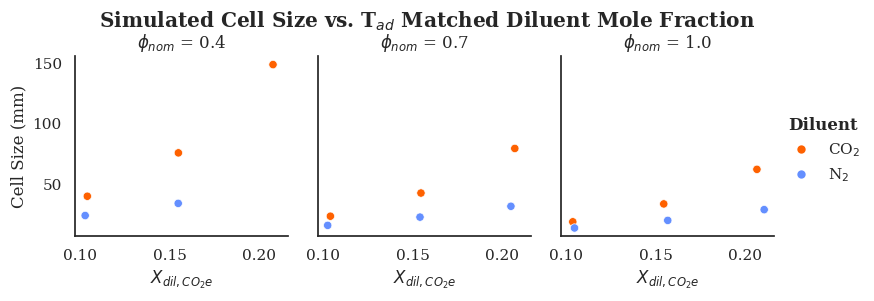

In [3]:
cell_size.simulated_vs_raw_mole_concentration.plot(cell_size_data_simulated)
cell_size.simulated_vs_co2_tad_normalized.plot(cell_size_data_simulated)

---
## Simulations vs. Measurements

When we look at the ratio of simulated to measured cell sizes, this time grouped by T$_{ad}$ matched CO$_{2}$-equivalent diluent mole fraction with equivalence ratio as the independent variable, we see that CO$_{2}$-diluted simulations tend to overpredict cell size relative to N$_{2}$-diluted simulations as the amount of dilution increases, while staying fairly consistent across equivalence ratios within a given level of dilution.

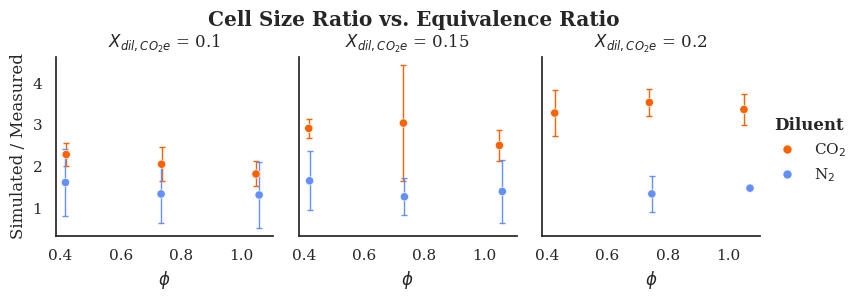

In [4]:
cell_size.ratio_vs_equivalence.plot(cell_size_data_ratio)

TODO: show equations and then investigate parts

### Speed

#### Wave Speed

We see that the measured wave speed is, across all conditions, reasonably predicted by the CJ speed. This indicates that the diluent-dependent divergence which we see between simulated and measured cell sizes is likely _not_ an equilibrium phenomenon. Therefore, we suspect that the divergence is driven by the rate-dependent portion of the simulations.

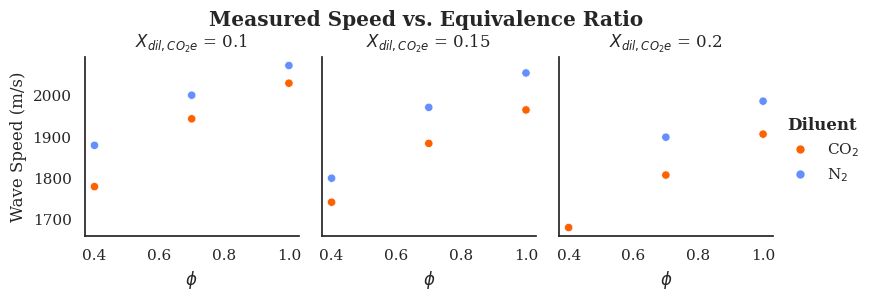

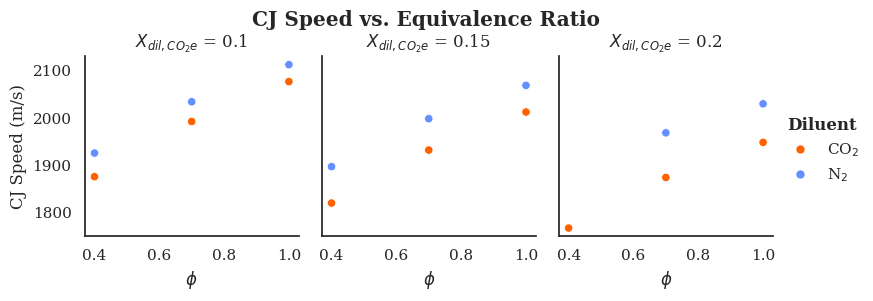

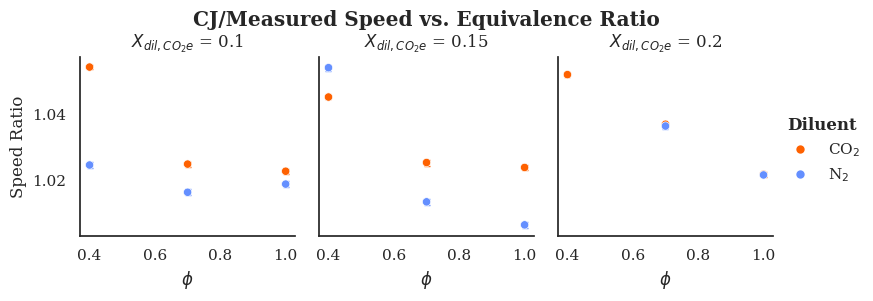

In [5]:
velocity.measured_speed_vs_equivalence.plot(sim_conditions)
velocity.cj_speed_vs_equivalence.plot(sim_conditions)
velocity.cj_ratio_vs_equivalence.plot(sim_conditions)

#### Sound Speed

Despite the fact that it is not an equilibrium simulation, we do not observe the pattern of deviation between CO$_{2}$ and N$_{2}$ diluted results that we see with cell size when we look at sound speed or mach number.

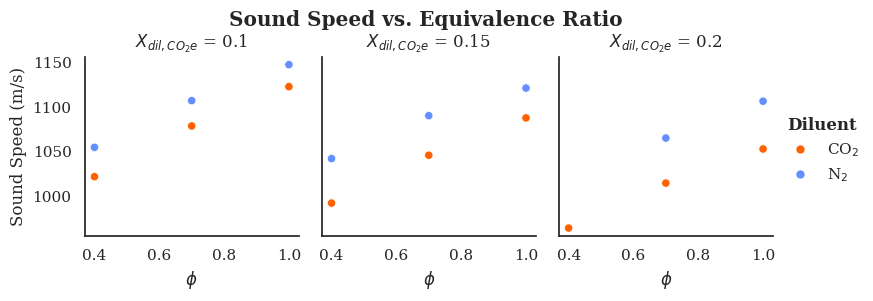

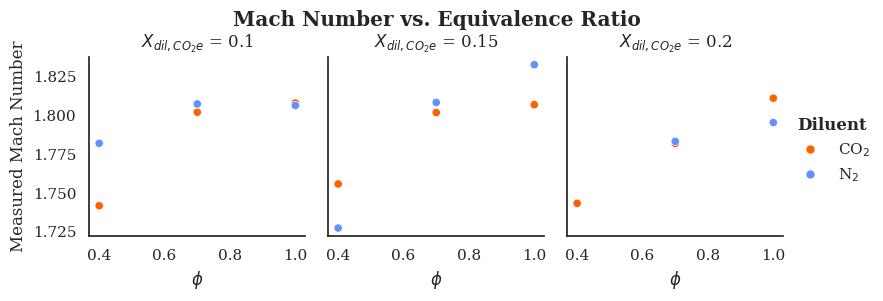

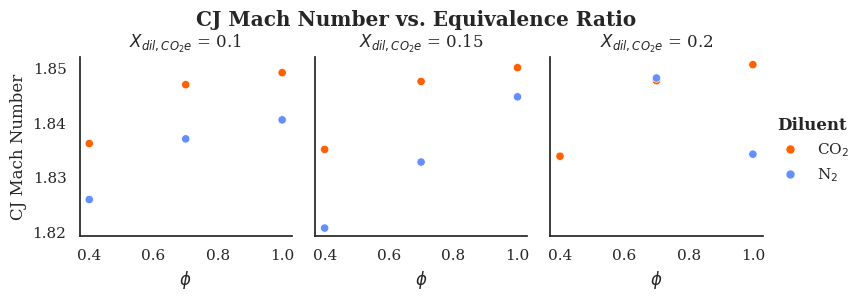

In [6]:
velocity.sound_speed_vs_equivalence.plot(sim_conditions)
velocity.mach_vs_equivalence.plot(sim_conditions)
velocity.cj_mach_vs_equivalence.plot(sim_conditions)

#### Conclusion

This exhausts the portions of the simulations which can be directly compared with measured data. We may still investigate the rate-resolved portion of the simulations, however, it will be trickier to probe whether the results can aid us on our search for the source of the deviations.

### Induction Time

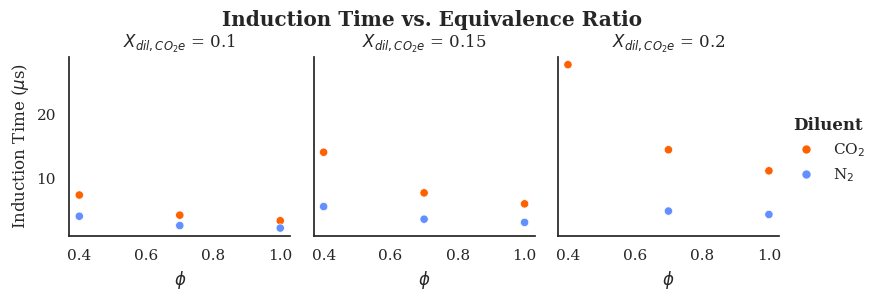

In [7]:
t_ind_vs_equivalence.plot(sim_conditions)

### Is it actually reaction rate based?

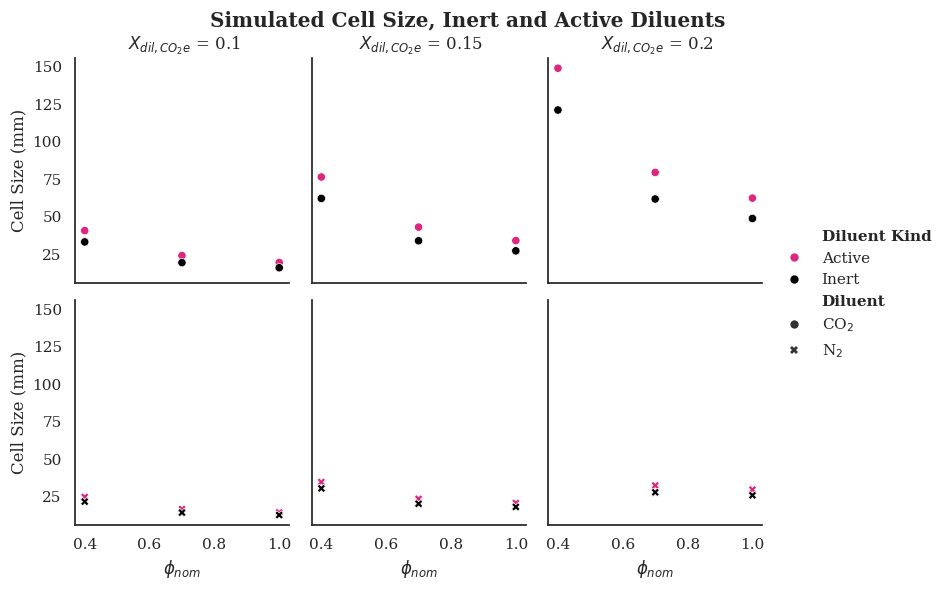

In [8]:
cell_size.inert.vs_active(sim_inert_and_active)

This shows us that N$_{2}$ is less active than CO$_{2}$, which is what we expected to see. However, this _also_ shows us that matching the adiabatic flame temperature does not give us insight into reaction kinetics vs. thermal effects as we had hoped; were that the case, the inert CO$_{2}$ would behave identically to the inert N$_{2}$. The following plot makes it more immediately clear that this is not the case.

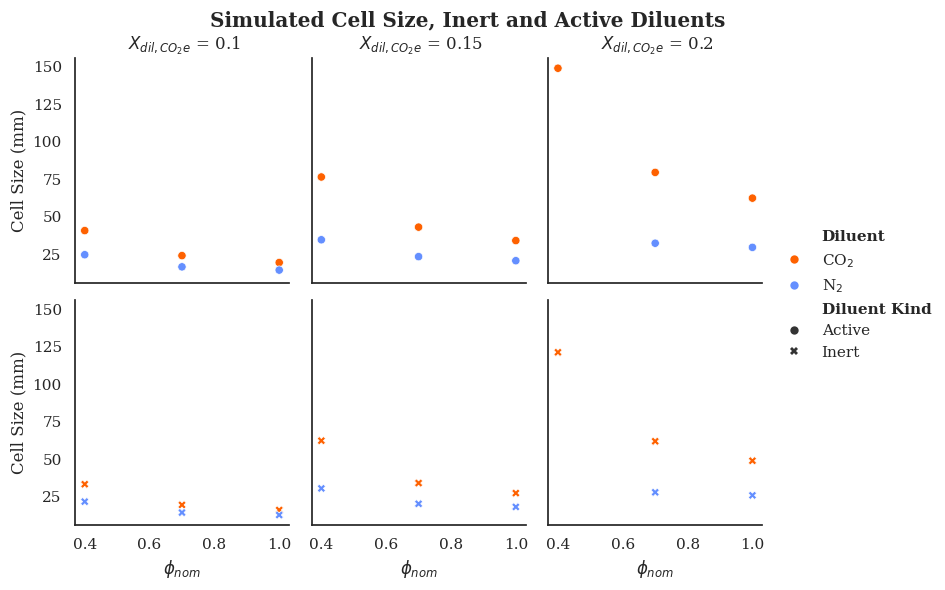

In [9]:
cell_size.inert.vs_active_2(sim_inert_and_active)

We can clearly see that the same diluent-specific, dilution-level-driven divergence between simulated-to-measured cell size ratios is present when we simulate cell sizes with both diluents made fully inert.

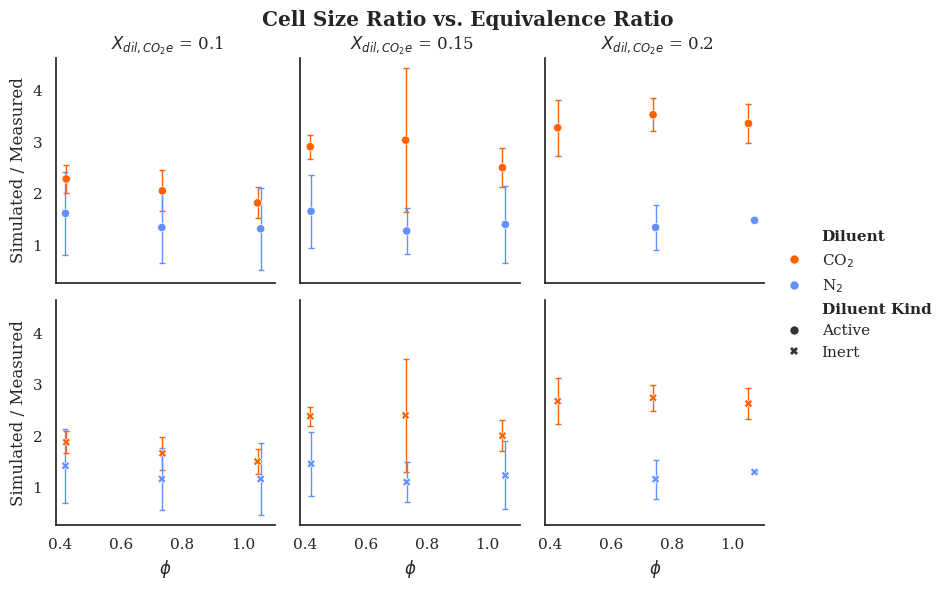

In [10]:
cell_size.inert.vs_measured(active=cell_size_data_ratio, inert=cell_size_data_ratio_inert)

So:
- We see a difference in simulated vs. measured behavior between mixtures diluted with CO$_{2}$ and those diluted with N$_{2}$,
- These differences are not evident in velocity, which is simulated via equilibrium methods, and so they may be driven _partly_ by reaction kinetics, however
- The differences are still apparent when simulations are run with fictitiously inert CO$_{2}$ and N$_{2}$

...so, what now? I am hesitant to start investigating reaction rates, since at least the bulk of the divergence appears to be due to something else entirely. This _does_ make me start to suspect the ideal gas equation of state again, however. Occam's razor points at my measurements.